### Pca Plots in 3D 
Change labelfile variable to change the words


**Uses** kqmw_embedding.json to plot



In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib
import random
import json
import os



from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting

def pca_plot(data, fpath, comparing, window, n_components=2):
    points = []
    for word in comparing:
        points.extend([word, np.array(row)] for row in data[word])
    random.shuffle(points)

    labels = np.array([point[0] for point in points])
    lookup, clabels = np.unique(labels, return_inverse=True)
    vectors = np.array([point[1] for point in points])

    pca = PCA(n_components=n_components)
    features_pca = pca.fit_transform(vectors)

    base_cmap = matplotlib.colormaps.get_cmap('tab10')
    colors = base_cmap(np.linspace(0, 1, len(comparing)))
    cmap = ListedColormap(colors)

    # Title + subtitle
    title = f"PCA of Words: {', '.join(comparing)}"
    subtitle = f"Window = {window}"

    if n_components == 2:
        fig, ax = plt.subplots(figsize=(5, 5))

        ax.scatter(features_pca[:, 0], features_pca[:, 1], c=clabels, cmap='tab10', s=5, marker='.')
        ax.set_xlabel('PC 1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
        ax.set_ylabel('PC 2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))

        ax.set_title(f"{title}\n{subtitle}", fontsize=12)

    elif n_components == 3:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')

        ax.scatter(features_pca[:, 0], features_pca[:, 1], features_pca[:, 2],
                   c=clabels, cmap='tab10', s=5)

        ax.set_xlabel('PC 1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
        ax.set_ylabel('PC 2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))
        ax.set_zlabel('PC 3 (%.2f%%)' % (pca.explained_variance_ratio_[2]*100))

        ax.set_title(f"{title}\n{subtitle}", fontsize=12)

        ax.invert_zaxis()

    else:
        raise ValueError("n_components must be 2 or 3 for plotting.")

    # Legend    
    legend_patches = [mpatches.Patch(color=cmap(b)) for b in range(len(comparing))]
    plt.legend(legend_patches, lookup)

    plt.savefig(fpath, dpi=300)
    plt.show()

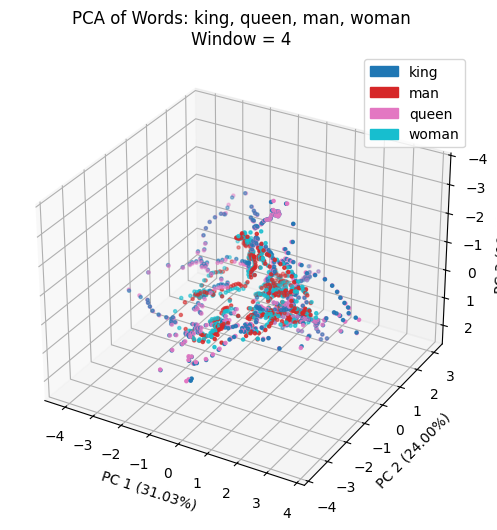

In [ ]:
window = 4
fpath = f'data/kqmw_iteration_window_{window}.json'

with open(fpath, 'r') as f:
    data = json.load(f)

words = list(data.keys())
prefix = ''.join([w[0] for w in words])

pca_plot(
    data,
    f'results/plots/{prefix}_iteration_snapshots_3D_window_{window}.png',
    words,
    window,
    n_components=3 #for 3d plotting
)